In [1]:
# %pip install mpl_interactions[jupyter]

In [2]:
pwd()

'/home/user/Documents/repos/pyptv/pyptv'

In [3]:
import optv
import pathlib
import os
import matplotlib.pyplot as plt


In [4]:
from optv.imgcoord import image_coordinates  # type: ignore
from optv.transforms import convert_arr_metric_to_pixel  # type: ignore
from optv.orientation import match_detection_to_ref  # type: ignore
from optv.orientation import external_calibration, full_calibration  # type: ignore
from optv.calibration import Calibration  # type: ignore
from optv.tracking_framebuf import TargetArray  # type: ignore

In [5]:
# PyPTV works only inside the working folder
# working_folder = pathlib.Path('../tests/test_cavity/')
working_folder = pathlib.Path('/home/user/Downloads/test_8/')
# working_folder = pathlib.Path('c:/Users/Alex/Downloads/test_8')
os.chdir(working_folder)


working_folder = pathlib.Path('.')
par_path = working_folder / "parameters"

In [6]:
with open(par_path / "ptv.par", "r", encoding="utf8") as f:
    n_cams = int(f.readline())
    
print(f'{n_cams} cameras setup')

4 cameras setup


In [7]:
from ptv import *

In [8]:
# Read all the parameters in respective structures
cpar, spar, vpar, track_par, tpar, cals, epar = py_start_proc_c(n_cams)

In [9]:
#check some parameters:
cpar.get_allCam_flag()


False

In [10]:

# this is the default targ_rec.par for images
tpar.get_grey_thresholds()

array([5, 5, 5, 5], dtype=int32)

In [11]:
# we need for calibration:
tpar.read(b"parameters/detect_plate.par")
tpar.get_grey_thresholds()

array([120, 125, 125, 125], dtype=int32)

In [12]:
import parameters as par
from skimage.util import img_as_ubyte

In [13]:
calParams = par.CalOriParams(n_cams, par_path)
calParams.read()

In [14]:
if epar.Combine_Flag is True:
    print("Combine Flag")
    MultiParams = par.MultiPlaneParams()
    MultiParams.read()
    for i in range(MultiParams.n_planes):
        print(MultiParams.plane_name[i])

    pass_raw_orient = True
    status_text = "Multiplane calibration."

In [15]:
# read calibration images
cal_images = []
for i in range(n_cams):
    imname = calParams.img_cal_name[i]
    # for imname in calParams.img_cal_name:
    # cal_images.append(imread(imname))
    im = imread(imname)
    if im.ndim > 2:
        im = rgb2gray(im)

    cal_images.append(img_as_ubyte(im))

In [16]:
camera_dict = {'man_ori':np.zeros((4,)), '_x':[], '_y':[]}

In [17]:
import copy
# Loading manual parameters here
man_ori_path =  par_path / "man_ori.par"
camera = []
with open(man_ori_path, "r", encoding='utf8') as f:
    for i in range(n_cams):
        camera.append(copy.deepcopy(camera_dict))
        for j in range(4):
            camera[i]["man_ori"][j] = int(f.readline().strip())

In [18]:
cals = []
for i_cam in range(n_cams):
    cal = Calibration()
    tmp = cpar.get_cal_img_base_name(i_cam)
    cal.from_file(tmp + b".ori", tmp + b".addpar")
    cals.append(cal)
    
for i_cam in range(n_cams):
    print(cals[i_cam].get_pos())

[-57.28759858  70.74876204 285.98923369]
[ 33.02346566  61.82391317 319.95354482]
[-88.8111167  -25.20251709 295.26823902]
[-12.2029431   -5.70212546 310.6248797 ]


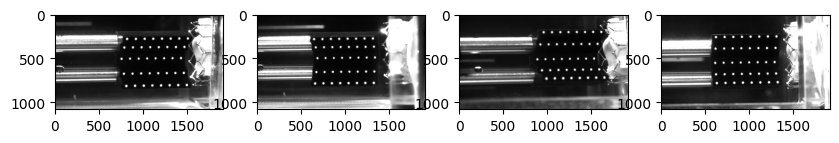

In [19]:
fig, ax = plt.subplots(1,4, figsize=(10,10))
                       
for i,c in enumerate(cal_images):
    ax[i].imshow(c, cmap='gray')
    # ax[i].plot(camera[i].man_ori[j])

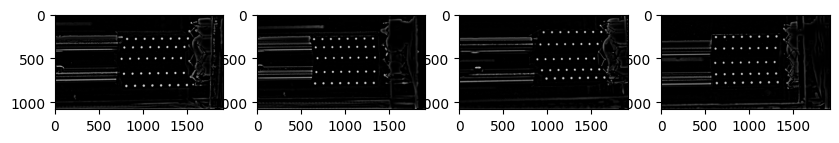

In [20]:
# highpass
high_passed = py_pre_processing_c(cal_images, cpar)

fig, ax = plt.subplots(1,4, figsize=(10,10))
                       
for i,c in enumerate(high_passed):
    ax[i].imshow(c, cmap='gray')
    # ax[i].plot(camera[i].man_ori[j])

In [21]:
detections, corrected = py_detection_proc_c(
    high_passed, cpar, tpar, cals)

In [22]:
x = [[i.pos()[0] for i in row] for row in detections]
y = [[i.pos()[1] for i in row] for row in detections]

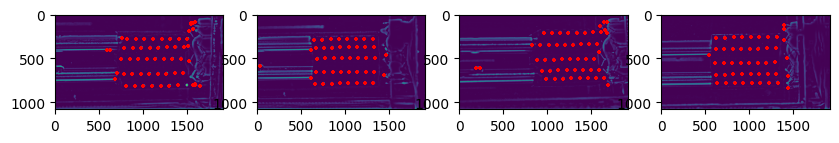

In [23]:
fig, ax = plt.subplots(1,n_cams,figsize=(10,10))
for i,c in enumerate(high_passed):
    ax[i].imshow(c)
    ax[i].scatter(x[i], y[i], 5, marker='+',color='r')

In [24]:
# interactive single camera detection cell
# change parameters by sliders
# high-pass the image
# apply detection
# visualize it
%matplotlib ipympl

import mpl_interactions.ipyplot as iplt

i_cam = 0

In [25]:

pftVersionParams = par.PftVersionParams(path="parameters")
pftVersionParams.read()
Existing_Target = bool(pftVersionParams.Existing_Target)


In [26]:
def detection(image=high_passed[i_cam], 
              cpar=cpar, 
              tpar=tpar, 
              cal=cals[i_cam], 
              i_cam=i_cam, 
              threshold=100, 
              minpix = 25, 
              maxpix = 500
             ):
    """ detection for a single camera """
    # adjust the threshold
    thresholds = tpar.get_grey_thresholds()
    thresholds[i_cam] = threshold
    tpar.set_grey_thresholds(thresholds)
            
    tpar.set_pixel_count_bounds((minpix, maxpix))
  

    # apply detection
    targs = target_recognition(image, tpar, i_cam, cpar)
    # sort by y - not sure necessary here
    # targs.sort_y()

    # somewhat clumsy conversion
    x = [row.pos()[0] for row in targs]
    y = [row.pos()[1] for row in targs]

    return np.c_[x,y]

from functools import partial 
g = partial(detection, high_passed[i_cam], cpar, tpar, cals[i_cam], i_cam)

TypeError: Invalid shape (4, 1080, 1920) for image data

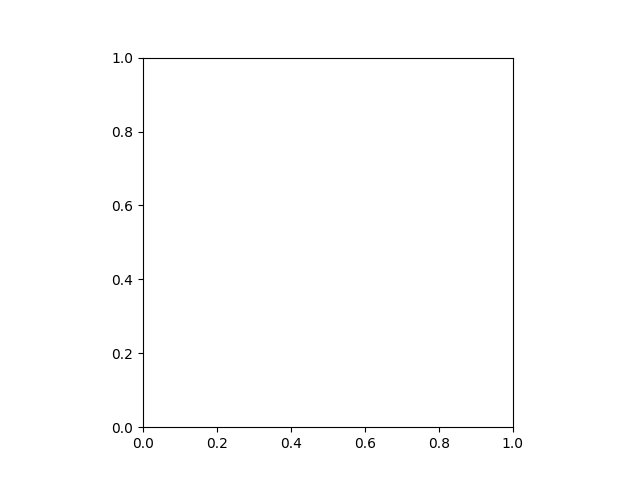

In [27]:
fig, ax = plt.subplots()
ax.imshow(high_passed_image, cmap='gray')
controls = iplt.scatter(g, 
                        ax=ax, 
                        threshold=np.linspace(100,190),
                        minpix=np.linspace(25,150), 
                        maxpix=np.linspace(160,700), 
                        parametric=True
                       )
plt.show()

# fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 4.8))
# controls = iplt.plot(f, ax=ax1, a=(0.5, 2), b=(0.1, 3), c_=(1, 3), d=(0.1, 2), parametric=True)
# ax1.set_xlabel("rabbits")
# ax1.set_ylabel("foxes")                        

# ax.scatter(x[N_camera], y[N_camera], 5, marker='+',color='r')
# ax[i].plot(camera[i].man_ori[j])
    

In [ ]:
fig, ax = plt.subplots(1, n_cams, figsize=(10,10))
man_ori_path = "man_ori.dat"
with open(man_ori_path, "r") as f:
    for i in range(n_cams):
        camera[i]["_x"], camera[i]["_y"] = [], []
        for j in range(4):  # 4 orientation points
            line = f.readline().split()
            # print(line)
            # print(float(line[0]), float(line[1]))
            camera[i]["_x"].append(float(line[0]))
            camera[i]["_y"].append(float(line[1]))
        
        print(camera[i]["_x"], camera[i]["_y"])
        
        ax[i].imshow(high_passed[i], cmap='gray')
        ax[i].scatter(camera[i]["_x"], camera[i]["_y"], marker='x',color='red')

In [ ]:
print(camera)

In [ ]:
# later use for manual clicks
# https://matplotlib.org/stable/gallery/event_handling/cursor_demo.html
# skip this for now

In [ ]:
def _read_cal_points():
    return np.atleast_1d(
        np.loadtxt(
            pathlib.Path(calParams.fixp_name), # calblock.txt
            dtype=[("id", "i4"), ("pos", "3f8")],
            skiprows=0,
        ))

cal_points = _read_cal_points()

In [ ]:
def drawcross(xlabel, ylabel, x, y, color, size, i_cam):
    ax[i_cam].scatter(x[i], y[i], 5, marker='+',color=color)

In [ ]:
def _project_cal_points(i_cam):
    x, y = [], []
    for row in cal_points:
        projected = image_coordinates(
            np.atleast_2d(row["pos"]),
            cals[i_cam],
            cpar.get_multimedia_params(),
        )
        pos = convert_arr_metric_to_pixel(projected, cpar)

        x.append(pos[0][0])
        y.append(pos[0][1])
        
    return x,y

In [ ]:
fig, ax = plt.subplots(1,n_cams,figsize=(10,10))
for i,c in enumerate(high_passed):
    ax[i].imshow(c)
    x,y = _project_cal_points(i)
    ax[i].scatter(x, y, 5, marker='+',color='y')

In [ ]:
# sortgrid
"""
Uses sortgrid function of liboptv to match between the
calibration points in the fixp target file and the targets
detected in the images
"""
sorted_targs = []
for i_cam in range(n_cams):
    fig, ax = plt.subplots(figsize=(6,6))

    targs = match_detection_to_ref(
        cals[i_cam],
        cal_points["pos"],
        detections[i_cam],
        cpar,
    )
    x, y, pnr = [], [], []
    for t in targs:
        if t.pnr() != -999:
            pnr.append(cal_points["id"][t.pnr()])
            x.append(t.pos()[0])
            y.append(t.pos()[1])

    ax.imshow(high_passed[i_cam])
    ax.scatter(x,y,marker='.', color='r')
    for xx,yy,ss in zip(x,y,pnr):
        ax.text(xx,yy,ss,color='r')
    # ax.text(x,y,pnr)
    
    sorted_targs.append(targs)

In [ ]:
print(camera)

In [ ]:
for i_cam in range(n_cams):
    print(i_cam)
    selected_points = np.zeros((4, 3))
    for i, cp_id in enumerate(cal_points["id"]):
        for j in range(4):
            if cp_id == camera[i_cam]["man_ori"][j]:
                selected_points[j, :] = cal_points["pos"][i, :]
                # print(cp_id, camera[i_cam].man_ori[j], selected_points[j,:])
                continue

    # in pixels:
    manual_detection_points = np.array(
        (camera[i_cam]["_x"], camera[i_cam]["_y"])).T
    
    print(manual_detection_points)
    print(selected_points)
    
    print('Before external calibration')
    print(cals[i_cam].get_pos())
    print(cals[i_cam].get_angles())

    success = external_calibration(
        cals[i_cam],
        selected_points,
        manual_detection_points,
        cpar,
    )
    print(success)
    print(cals[i_cam].get_pos())
    print(cals[i_cam].get_angles())

In [ ]:
# sortgrid
"""
Uses sortgrid function of liboptv to match between the
calibration points in the fixp target file and the targets
detected in the images
"""
sorted_targs = []
for i_cam in range(n_cams):
    fig, ax = plt.subplots(figsize=(6,6))

    targs = match_detection_to_ref(
        cals[i_cam],
        cal_points["pos"],
        detections[i_cam],
        cpar,
    )
    x, y, pnr = [], [], []
    for t in targs:
        if t.pnr() != -999:
            pnr.append(cal_points["id"][t.pnr()])
            x.append(t.pos()[0])
            y.append(t.pos()[1])

    ax.imshow(high_passed[i_cam])
    ax.scatter(x,y,marker='.', color='r')
    for xx,yy,ss in zip(x,y,pnr):
        ax.text(xx,yy,ss,color='r')
    # ax.text(x,y,pnr)
    
    sorted_targs.append(targs)

In [ ]:
# full calibration

"""
fine tuning of ORI and ADDPAR

"""
scale = 5000

op = par.OrientParams()
op.read()

# recognized names for the flags:
names = [
    "cc",
    "xh",
    "yh",
    "k1",
    "k2",
    "k3",
    "p1",
    "p2",
    "scale",
    "shear",
]
op_names = [
    op.cc,
    op.xh,
    op.yh,
    op.k1,
    op.k2,
    op.k3,
    op.p1,
    op.p2,
    op.scale,
    op.shear,
]

flags = []
for name, op_name in zip(names, op_names):
    if op_name == 1:
        flags.append(name)

print(flags)

In [ ]:
sum_residuals = []
for num_iterations in range(10):
    # for num_iterations in range(1000):
    for i_cam in range(n_cams):  # iterate over all cameras

        targs = sorted_targs[i_cam]

        # print('Before fine tuning')
        # print(cals[i_cam].get_pos())
        # print(cals[i_cam].get_angles())

        pos = cals[i_cam].get_pos()
        ang = cals[i_cam].get_angles()

        residuals, targ_ix, err_est = full_calibration(
            cals[i_cam],
            cal_points["pos"],
            targs,
            cpar,
            flags,
        )

        sum_residuals.append(np.sum(residuals))

In [ ]:
# # save the results
# _write_ori(i_cam, addpar_flag=True)

# # Plot the output
# # reset_plots()

# x, y = [], []
# for r, t in zip(residuals, targ_ix):
#     if t != -999:
#         pos = targs[t].pos()
#         x.append(pos[0])
#         y.append(pos[1])

# camera[i_cam]._plot.overlays.clear()
# drawcross("orient_x",
#                "orient_y",
#                x,
#                y,
#                "orange",
#                5,
#                i_cam=i_cam)

# # camera[i]._plot_data.set_data(
# #     'imagedata', ori_img[i].astype(np.float))
# # camera[i]._img_plot = camera[
# #     i]._plot.img_plot('imagedata', colormap=gray)[0]
# camera[i_cam].drawquiver(
#     x,
#     y,
#     x + scale * residuals[:len(x), 0],
#     y + scale * residuals[:len(x), 1],
#     "red",
# )
# # camera[i]._plot.index_mapper.range.set_bounds(0, h_pixel)
# # camera[i]._plot.value_mapper.range.set_bounds(0, v_pixel)

# status_text = "Orientation finished."

In [ ]:
# from pbi 
def fitness(solution, calib_targs, calib_detect, cpar):
    """
    Checks the fitness of an evolutionary solution of calibration values to 
    target points. Fitness is the sum of squares of the distance from each 
    guessed point to the closest neighbor.
    
    Arguments:
    solution - array, concatenated: position of intersection with Z=0 plane; 3 
        angles of exterior calibration; primary point (xh,yh,cc); 3 radial
        distortion parameters; 2 decentering parameters.
    calib_targs - a (p,3) array of p known points on the calibration target.
    calib_detect - a (d,2) array of d detected points in the calibration 
        target.
    cpar - a ControlParams object with image data.
    """
    # Breakdown of of agregate solution vector:
    inters = np.zeros(3)
    inters[:2] = solution[:2]
    R = solution[2]
    angs = solution[3:6]
    prim_point = solution[6:9]
    rad_dist = solution[9:12]
    decent = solution[12:14]
    
    # Compare known points' projections to detections:
    cal = gen_calib(inters, R, angs, glass_vec, prim_point, rad_dist,
                    decent)
    known_proj = image_coordinates(calib_targs, cal,
                                    cpar.get_multimedia_params())
    known_2d = convert_arr_metric_to_pixel(known_proj, cpar)
    dists = np.linalg.norm(known_2d[None, :, :] - calib_detect[:, None, :],
                            axis=2).min(axis=0)

    return np.sum(dists**2)

In [ ]:
def full_calibration(
                    cal: Calibration,
                    calib_detect: np.ndarray,
                    calib_targs: np.ndarray,
                    cpar: ControlParams,
                    flags,
                )-> Calibration:
    """ New full calibration using scipy minimize

    Returns:
        _type_: _description_
    """
    
    # define partial function to keep the arguments
    solution = parse_calib(cal)
    res = minimize(fitness, 
                            solution,
                            args = (
                                calib_targs, 
                                calib_detect, 
                                cpar)
    )
    
    res_cal = gen_calib(res)

    # res is the cal object that minimizes the fitness
    err_est = fitness(res_cal, calib_targs, calib_detect, cpar)
    

    return res_cal, err_est

In [ ]:
def get_pos(inters, R, angs):
    # Transpose of http://planning.cs.uiuc.edu/node102.html
    # Also consider the angles are reversed when moving from camera frame to
    # global frame.
    s = np.sin(angs)
    c = np.cos(angs)
    pos = inters + R*np.r_[ s[1], -c[1]*s[0], c[1]*c[0] ]
    return pos

In [ ]:
def get_polar_rep(pos, angs):
    """
    Returns the point of intersection with zero Z plane, and distance from it.
    """
    s = np.sin(angs)
    c = np.cos(angs)
    zdir = -np.r_[ s[1], -c[1]*s[0], c[1]*c[0] ]
    
    c = -pos[2]/zdir[2]
    inters = pos + c*zdir
    R = np.linalg.norm(inters - pos)
    
    return inters[:2], R

In [ ]:
def gen_calib(inters, R, angs, glass_vec, prim_point, radial_dist, decent):
    pos = get_pos(inters, R, angs)
    return Calibration(pos, angs, prim_point, radial_dist, decent, 
        np.r_[1, 0], glass_vec)

In [ ]:
    
def parse_calib(
    cal: Calibration
    )-> np.ndarray:
    """parse calibration to solution

    Args:
        cal (Calibration): _description_

    Returns:
        np.ndarray: solution array
    """
    
    # Inverse it: 
    
    # Breakdown of of agregate solution vector:
    # inters = np.zeros(3)
    # inters[:2] = solution[:2]
    # R = solution[2]
    # angs = solution[3:6]
    # prim_point = solution[6:9]
    # rad_dist = solution[9:12]
    # decent = solution[12:14]
    
    inters = cal.get_pos() # including R
    angs = cal.get_angles()
    primary_point = cal.get_primary_point()
    rad_dist = cal.get_radial_distortion()
    decent = cal.get_decentering()
    
    return np.r_[inters, angs, primary_point, rad_dist, decent]

In [ ]:
def copy_calibration(cal):
    return Calibration(cal.get_pos(), 
                      cal.get_angles(), 
                      cal.get_primary_point(), 
                      cal.get_radial_distortion(), 
                      cal.get_decentering(), 
                      cal.get_affine(), 
                      cal.get_glass_vec())
    

In [ ]:
def project_cal_points(cal_points, calibration, cpar):
    x, y = [], []
    for row in cal_points:
        projected = image_coordinates(
            np.atleast_2d(row["pos"]),
            calibration,
            cpar.get_multimedia_params(),
        )
        pos = convert_arr_metric_to_pixel(projected, cpar)

        x.append(pos[0][0])
        y.append(pos[0][1])
        
    return x,y

In [ ]:
def get_targs(calibration, cal_points, detections, cpar):
    """gets matching targets in x,y """
    targs = match_detection_to_ref(
        calibration,
        cal_points["pos"],
        detections,
        cpar,
    )
    x, y, pnr = [], [], []
    for t in targs:
        if t.pnr() != -999:
            pnr.append(cal_points["id"][t.pnr()])
            x.append(t.pos()[0])
            y.append(t.pos()[1])
    return x,y


In [ ]:
# for i_cam in range(1):
i_cam = 0
fig, ax = plt.subplots(figsize=(12,12))


tmp = copy_calibration(cals[i_cam])
solution = parse_calib(tmp)
print(f'solution is {solution}')

x,y = get_targs(tmp, cal_points, detections[i_cam], cpar)


ax.imshow(high_passed[i_cam],cmap='gray')
ax.scatter(x,y,marker='.', color='r')
for xx,yy,ss in zip(x,y,pnr):
    ax.text(xx,yy,ss,color='r')

xc,yc = project_cal_points(cal_points, tmp, cpar)
ax.scatter(xc, yc, 30, marker='+',color='g')
known_2d = np.c_[xc,yc]
calib_detect = np.c_[x,y]

dists = np.linalg.norm(known_2d[None, :, :] - calib_detect[:, None, :],
                        axis=2).min(axis=0)


print(f'error is {np.sum(dists**2)}')
    
    # return np.sum(dists**2)
    

In [ ]:
# for i_cam in range(1):
i_cam = 0
fig, ax = plt.subplots(figsize=(12,12))


tmp = copy_calibration(cals[i_cam])

# change one parameter at a time

eps = 0.01
# print(tmp.get_radial_distortion())


tmp.set_radial_distortion(tmp.get_radial_distortion() + np.array([eps, 0, 0]))
# print(tmp.get_radial_distortion())
# solution = parse_calib(tmp)
print(f'solution is {parse_calib(tmp)}')


x,y = get_targs(tmp, cal_points, detections[i_cam], cpar)


ax.imshow(high_passed[i_cam],cmap='gray')
ax.scatter(x,y,marker='.', color='r')
for xx,yy,ss in zip(x,y,pnr):
    ax.text(xx,yy,ss,color='r')

xc,yc = project_cal_points(cal_points, tmp, cpar)
ax.scatter(xc, yc, 30, marker='+',color='g')
known_2d = np.c_[xc,yc]
calib_detect = np.c_[x,y]

dists = np.linalg.norm(known_2d[None, :, :] - calib_detect[:, None, :],
                        axis=2).min(axis=0)


print(f'error is {np.sum(dists**2)}')

In [ ]:
# Explanation of the Calibration structure

# from calibration.pyx and calibration.pxd in optv:
# pos = exterior.x0,y0,z0
# angles = exterior. omega, phi, kappa
# primary point = xh, yh, cc
# glass = x,y,z
# radial_distortion = k1,k2,k3, works in r = x**2 + y**2, p = k1 r**2 + k2 r**4 + k3 r**6
# decentering = p1, p2
# affine = scale, shear

In [ ]:
i_cam = 0
# , ax = plt.subplots(figsize=(12,12))
tmp = copy_calibration(cals[i_cam])

def fitness(eps):
   
    rd = tmp.get_radial_distortion()
    rd[2] = eps
    tmp.set_radial_distortion(rd)

    x,y = get_targs(tmp, cal_points, detections[i_cam], cpar)
    xc,yc = project_cal_points(cal_points, tmp, cpar)
    
    known_2d = np.c_[xc,yc]
    calib_detect = np.c_[x,y]

    dists = np.linalg.norm(known_2d[None, :, :] - calib_detect[:, None, :],
                            axis=2).min(axis=0)
    
    return np.sum(dists**2)

In [ ]:
from scipy.optimize import minimize
sol = minimize(fitness, 0. , method='Nelder-Mead',options ={'disp':True, 'xatol': 1e-6})

In [ ]:
sol.x

In [ ]:
# for i_cam in range(1):

fig, ax = plt.subplots(figsize=(12,12))

tmp = copy_calibration(cals[i_cam])

rd = tmp.get_radial_distortion()
rd[1] = sol.x
tmp.set_radial_distortion(rd)

solution = parse_calib(tmp)
print(f'solution is {solution}')

x,y = get_targs(tmp, cal_points, detections[i_cam], cpar)


ax.imshow(high_passed[i_cam],cmap='gray')
ax.scatter(x,y,marker='.', color='r')
for xx,yy,ss in zip(x,y,pnr):
    ax.text(xx,yy,ss,color='r')

xc,yc = project_cal_points(cal_points, tmp, cpar)
ax.scatter(xc, yc, 30, marker='+',color='g')
known_2d = np.c_[xc,yc]
calib_detect = np.c_[x,y]

dists = np.linalg.norm(known_2d[None, :, :] - calib_detect[:, None, :],
                        axis=2).min(axis=0)


print(f'error is {np.sum(dists**2)}')

In [ ]:
# Now it's about time to run the complete calibration again, with k1 modified and pos() and angles(), to get the 
# new sortgrid and then the new calibration again? 
#